# Stage 10 — Model Evaluation and Hyperparameter Tuning

The test set is used for final evaluation, not for feature selection or hyperparameter tuning. Model choice is based on training cross-validation.

## 10.1 Initial test evaluation for reporting

In [714]:
initial_test_rows = []

for model_name, pipeline in fitted_initial_models.items():
    test_pred = pipeline.predict(X_test)
    metrics = evaluate_predictions(y_test, test_pred)
    initial_test_rows.append({"model": model_name, **metrics})

initial_test_results = pd.DataFrame(initial_test_rows).sort_values("rmse_log")
initial_test_results.to_csv(TABLE_DIR / "initial_test_model_comparison.csv", index=False)
display(initial_test_results)

,model,rmse_log,mae_log,r2_log,mae_original_scale
5,Extra Trees,0.346424,0.270311,0.899008,6.887858
4,Random Forest,0.371681,0.297828,0.883744,7.248726
6,Gradient Boosting,0.374367,0.291175,0.882058,7.318576
3,KNN,0.442442,0.337170,0.835265,7.401257
1,Ridge,0.600008,0.390292,0.697039,12.824884
2,ElasticNet,0.704211,0.577577,0.582671,13.658437
0,Dummy mean,1.091368,0.885276,-0.002340,18.507869


## 10.2 Model comparison plot

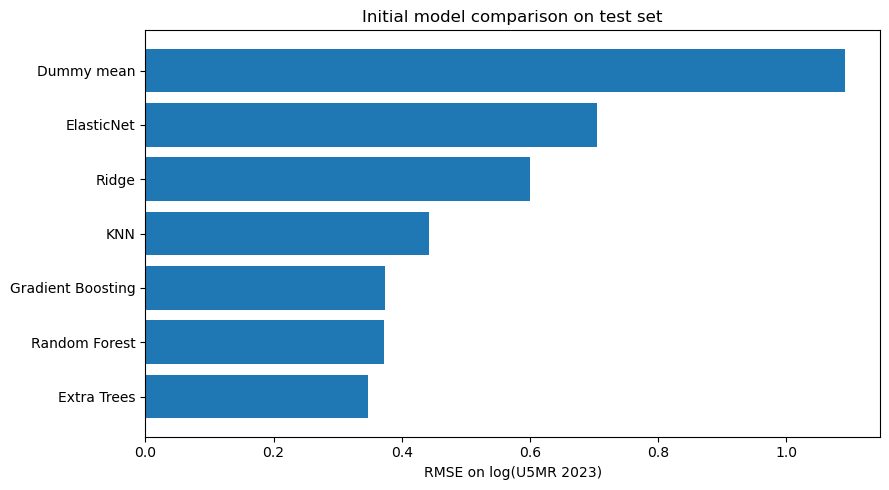

In [716]:
plot_df = initial_test_results.sort_values("rmse_log", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["rmse_log"])
plt.title("Initial model comparison on test set")
plt.xlabel("RMSE on log(U5MR 2023)")
plt.tight_layout()
plt.savefig(VIS_DIR / "initial_model_comparison_rmse_log.png", dpi=300)
plt.show()

## 10.3 Modest hyperparameter tuning on training data only

In [718]:
top_models_for_tuning = cv_results[cv_results["model"] != "Dummy mean"].head(3)["model"].tolist()
print("Models selected for tuning based on training CV:", top_models_for_tuning)

param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "Random Forest": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Extra Trees": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [1, 3, 5]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    }
}

tuning_rows = []
tuned_models = {}

for model_name in top_models_for_tuning:
    if model_name not in param_grids:
        continue

    total_combinations = int(np.prod([len(v) for v in param_grids[model_name].values()]))
    search = RandomizedSearchCV(
        estimator=model_catalogue[model_name],
        param_distributions=param_grids[model_name],
        n_iter=min(10, total_combinations),
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_models[model_name + " tuned"] = search.best_estimator_
    tuning_rows.append({
        "model": model_name + " tuned",
        "cv_rmse_log_mean": -search.best_score_,
        "best_params": search.best_params_
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("cv_rmse_log_mean")
tuning_results.to_csv(TABLE_DIR / "tuning_results_train_only.csv", index=False)
display(tuning_results)

Models selected for tuning based on training CV: ['Extra Trees', 'Random Forest', 'Gradient Boosting']


,model,cv_rmse_log_mean,best_params
0,Extra Trees tuned,0.366080,"{'model__n_estimators': 300, 'model__min_sampl..."
1,Random Forest tuned,0.369594,"{'model__n_estimators': 600, 'model__min_sampl..."
2,Gradient Boosting tuned,0.378526,"{'model__n_estimators': 100, 'model__min_sampl..."


## 10.4 Select the final model using training CV only

In [720]:
initial_cv_for_selection = cv_results[cv_results["model"] != "Dummy mean"][["model", "cv_rmse_log_mean"]].copy()
combined_cv_selection = pd.concat([
    initial_cv_for_selection,
    tuning_results[["model", "cv_rmse_log_mean"]] if len(tuning_results) else pd.DataFrame(columns=["model", "cv_rmse_log_mean"])
], ignore_index=True).sort_values("cv_rmse_log_mean")

final_model_name = combined_cv_selection.iloc[0]["model"]

if final_model_name in tuned_models:
    final_model = tuned_models[final_model_name]
else:
    final_model = fitted_initial_models[final_model_name]

final_model.fit(X_train, y_train)
print("Final selected model based on training CV:", final_model_name)
display(combined_cv_selection)

Final selected model based on training CV: Extra Trees tuned


,model,cv_rmse_log_mean
6,Extra Trees tuned,0.366080
7,Random Forest tuned,0.369594
0,Extra Trees,0.371552
1,Random Forest,0.376973
8,Gradient Boosting tuned,0.378526
2,Gradient Boosting,0.385421
3,KNN,0.431822
4,Ridge,0.452898
5,ElasticNet,0.748254


## 10.5 Final test evaluation

In [722]:
final_test_pred_log = final_model.predict(X_test)
dummy_test_pred_log = fitted_initial_models["Dummy mean"].predict(X_test)

final_metrics = evaluate_predictions(y_test, final_test_pred_log)
dummy_metrics = evaluate_predictions(y_test, dummy_test_pred_log)

improvement_over_dummy = 100 * (dummy_metrics["rmse_log"] - final_metrics["rmse_log"]) / dummy_metrics["rmse_log"]

final_evaluation = pd.DataFrame([
    {"model": final_model_name, **final_metrics, "improvement_over_dummy_pct": improvement_over_dummy},
    {"model": "Dummy mean", **dummy_metrics, "improvement_over_dummy_pct": 0.0}
])

final_evaluation.to_csv(TABLE_DIR / "final_test_evaluation.csv", index=False)
display(final_evaluation)

,model,rmse_log,mae_log,r2_log,mae_original_scale,improvement_over_dummy_pct
0,Extra Trees tuned,0.346159,0.269338,0.899162,6.768375,68.282062
1,Dummy mean,1.091368,0.885276,-0.002340,18.507869,0.000000


## 10.6 Bootstrap uncertainty for final test metrics

In [724]:
bootstrap_rows = []
rng = np.random.default_rng(RANDOM_STATE)
y_test_array = np.asarray(y_test)
pred_array = np.asarray(final_test_pred_log)

for _ in range(500):
    sample_idx = rng.integers(0, len(y_test_array), size=len(y_test_array))
    y_boot = y_test_array[sample_idx]
    pred_boot = pred_array[sample_idx]
    bootstrap_rows.append(evaluate_predictions(y_boot, pred_boot))

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci = bootstrap_df.quantile([0.025, 0.5, 0.975]).T.rename(columns={0.025: "ci_2_5", 0.5: "median", 0.975: "ci_97_5"})
bootstrap_ci.to_csv(TABLE_DIR / "final_test_metric_bootstrap_ci.csv")
display(bootstrap_ci)

,ci_2_5,median,ci_97_5
rmse_log,0.270589,0.341554,0.409121
mae_log,0.212040,0.269366,0.325239
r2_log,0.838261,0.897094,0.937808
mae_original_scale,3.876839,6.640603,9.883233


## 10.7 Save final predictions

In [726]:
final_predictions = test_model_data[["country_code", "country_name", "u5mr_2023", "log_u5mr_2023"]].copy()
final_predictions["pred_log_u5mr_2023"] = final_test_pred_log
final_predictions["pred_u5mr_2023"] = np.exp(final_test_pred_log)
final_predictions["residual_log"] = final_predictions["log_u5mr_2023"] - final_predictions["pred_log_u5mr_2023"]
final_predictions["absolute_error_original"] = (final_predictions["u5mr_2023"] - final_predictions["pred_u5mr_2023"]).abs()

final_predictions.to_csv(DATA_DIR / "final_test_predictions.csv", index=False)
display(final_predictions.sort_values("absolute_error_original", ascending=False).head(10))

,country_code,country_name,u5mr_2023,log_u5mr_2023,pred_log_u5mr_2023,pred_u5mr_2023,residual_log,absolute_error_original
124,SOM,"Somalia, Federal Republic of",104.0,4.644391,3.796010,44.523163,0.848381,59.476837
170,SLE,Sierra Leone,94.3,4.546481,3.972095,53.095661,0.574386,41.204339
107,MLI,Mali,91.3,4.514151,4.049329,57.358948,0.464822,33.941052
159,TCD,Chad,101.1,4.616110,4.405729,81.918819,0.210381,19.181181
54,LSO,Lesotho,58.9,4.075841,3.736525,41.951942,0.339316,16.948058
142,CIV,Côte d’Ivoire,67.1,4.206184,3.976186,53.313309,0.229998,13.786691
129,PLW,Palau,22.3,3.104587,2.220251,9.209646,0.884335,13.090354
34,LBY,Libya,30.8,3.427515,2.878581,17.789012,0.548934,13.010988
91,UGA,Uganda,38.8,3.658420,3.919336,50.367011,-0.260916,11.567011
144,CPV,Cabo Verde,11.6,2.451005,3.126071,22.784290,-0.675066,11.184290


## 10.8 Subgroup error analysis

Overall RMSE and MAE can hide uneven performance across groups of countries. This diagnostic section evaluates errors by U5MR level and, when available, by an income proxy from WDI. The subgroup analysis is not used for model selection; it is used only to understand where the final model performs better or worse.

The groups are built only after final model evaluation, so they do not affect training, feature selection, or tuning.

No sufficiently complete WDI income proxy was available for test-country subgroup analysis.


,grouping_variable,group,n_countries,mean_actual_u5mr,median_actual_u5mr,mae_original_scale,rmse_log,mean_residual_log_actual_minus_predicted
0,u5mr_test_quartile,highest U5MR countries,12,67.483333,63.25,18.075836,0.367241,0.187995
1,u5mr_test_quartile,lower-middle U5MR countries,12,12.083333,12.70,3.007607,0.276719,-0.072658
2,u5mr_test_quartile,lowest U5MR countries,13,3.807692,3.70,1.346638,0.371130,-0.096710
3,u5mr_test_quartile,upper-middle U5MR countries,12,22.966667,22.70,5.095230,0.358658,0.139312


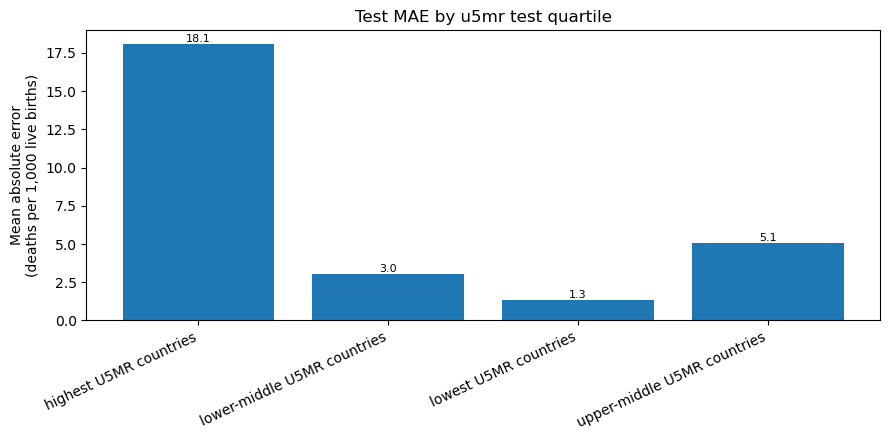

In [728]:
# ------------------------------------------------------------
# Subgroup error analysis on the held-out test countries
# ------------------------------------------------------------

def make_quantile_groups(series, labels):
    """Create quantile groups with robust handling of tied values."""
    series = pd.Series(series)
    try:
        codes = pd.qcut(series, q=len(labels), labels=False, duplicates="drop")
        if codes.notna().sum() == 0:
            return pd.Series(pd.NA, index=series.index, dtype="object")
        n_groups = int(codes.max()) + 1
        label_map = {i: labels[i] for i in range(n_groups)}
        return codes.map(label_map).astype("object")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="object")

# U5MR-level groups are always available and show whether errors differ between
# low-, middle-, and high-mortality countries.
u5mr_group_labels = [
    "lowest U5MR countries",
    "lower-middle U5MR countries",
    "upper-middle U5MR countries",
    "highest U5MR countries"
]
final_predictions["u5mr_test_quartile"] = make_quantile_groups(
    final_predictions["u5mr_2023"],
    u5mr_group_labels
)

# Income proxy groups are useful for policy interpretation. The raw WDI file does
# not provide an official income-group column, so the notebook uses a 2022 income
# proxy if available. This is a diagnostic grouping only, not a model feature.
income_proxy_candidates = [
    ("NY.GNP.PCAP.CD", "GNI per capita, Atlas method, current US$"),
    ("NY.GDP.PCAP.CD", "GDP per capita, current US$"),
    ("NY.GDP.PCAP.KD", "GDP per capita, constant 2015 US$"),
]

best_income_proxy = None
best_income_proxy_label = None
best_income_proxy_coverage = -1

for indicator_code, indicator_label in income_proxy_candidates:
    candidate_rows = country_wdi[country_wdi["indicator_code"] == indicator_code].copy()
    if candidate_rows.empty:
        continue

    candidate_values = (
        fixed_year_values(
            candidate_rows,
            PREDICTOR_LEVEL_YEAR,
            value_name="income_proxy_2022"
        )[["country_code", "income_proxy_2022"]]
        .drop_duplicates(subset=["country_code"])
    )

    coverage = (
        final_predictions[["country_code"]]
        .merge(candidate_values, on="country_code", how="left")["income_proxy_2022"]
        .notna()
        .mean()
    )

    if coverage > best_income_proxy_coverage:
        best_income_proxy = candidate_values
        best_income_proxy_label = indicator_label
        best_income_proxy_coverage = coverage

if best_income_proxy is not None and best_income_proxy_coverage >= 0.50:
    final_predictions = final_predictions.merge(best_income_proxy, on="country_code", how="left")
    income_group_labels = [
        "lowest income-proxy countries",
        "lower-middle income-proxy countries",
        "upper-middle income-proxy countries",
        "highest income-proxy countries"
    ]
    final_predictions["income_proxy_quartile"] = make_quantile_groups(
        final_predictions["income_proxy_2022"],
        income_group_labels
    )
    print(f"Income proxy used for subgroup analysis: {best_income_proxy_label}")
    print(f"Income proxy coverage in test set: {best_income_proxy_coverage:.1%}")
else:
    final_predictions["income_proxy_2022"] = np.nan
    final_predictions["income_proxy_quartile"] = pd.NA
    print("No sufficiently complete WDI income proxy was available for test-country subgroup analysis.")


def subgroup_metric_table(prediction_df, group_column):
    rows = []
    valid_df = prediction_df.dropna(subset=[group_column]).copy()

    for group_value, group_df in valid_df.groupby(group_column, observed=True):
        if len(group_df) == 0:
            continue

        rmse_log_group = np.sqrt(
            np.mean((group_df["log_u5mr_2023"] - group_df["pred_log_u5mr_2023"]) ** 2)
        )

        rows.append({
            "grouping_variable": group_column,
            "group": str(group_value),
            "n_countries": len(group_df),
            "mean_actual_u5mr": group_df["u5mr_2023"].mean(),
            "median_actual_u5mr": group_df["u5mr_2023"].median(),
            "mae_original_scale": group_df["absolute_error_original"].mean(),
            "rmse_log": rmse_log_group,
            "mean_residual_log_actual_minus_predicted": group_df["residual_log"].mean()
        })

    return pd.DataFrame(rows)

subgroup_tables = [subgroup_metric_table(final_predictions, "u5mr_test_quartile")]

if final_predictions["income_proxy_quartile"].notna().sum() >= 8:
    subgroup_tables.append(subgroup_metric_table(final_predictions, "income_proxy_quartile"))

subgroup_error_table = pd.concat(subgroup_tables, ignore_index=True)
subgroup_error_table.to_csv(TABLE_DIR / "subgroup_error_analysis_test_set.csv", index=False)
final_predictions.to_csv(DATA_DIR / "final_test_predictions_with_subgroups.csv", index=False)

display(subgroup_error_table)

# Plot subgroup MAE on the original U5MR scale.
for group_var in subgroup_error_table["grouping_variable"].unique():
    plot_df = subgroup_error_table[subgroup_error_table["grouping_variable"] == group_var].copy()

    plt.figure(figsize=(9, 4.5))
    plt.bar(plot_df["group"], plot_df["mae_original_scale"])
    plt.title(f"Test MAE by {group_var.replace('_', ' ')}")
    plt.ylabel("Mean absolute error\n(deaths per 1,000 live births)")
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")

    for i, value in enumerate(plot_df["mae_original_scale"]):
        plt.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    safe_group_name = group_var.replace(" ", "_").lower()
    plt.savefig(VIS_DIR / f"test_mae_by_{safe_group_name}.png", dpi=300)
    plt.show()


### Subgroup-error interpretation

The subgroup table should be read as a diagnostic check, not as a separate model-selection procedure. Some groups contain few countries, so differences in subgroup MAE or RMSE can be unstable. Nevertheless, the table is useful because it shows whether the model errors are concentrated among low-mortality, high-mortality, lower-income, or higher-income countries.

## 10.8 Actual vs predicted plot

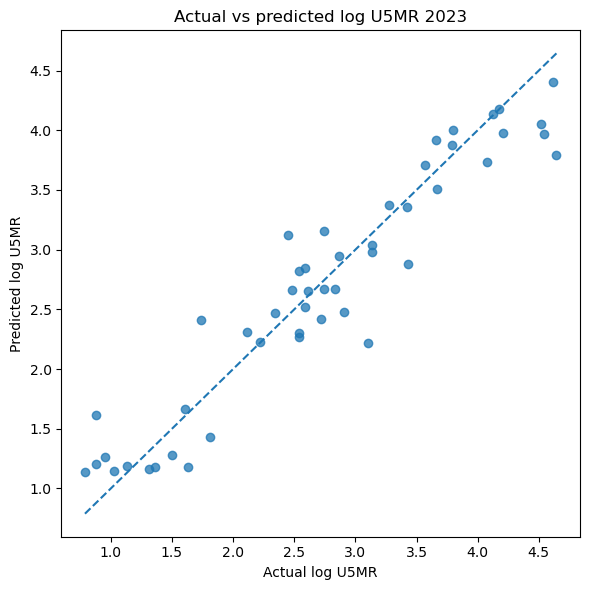

In [731]:
plt.figure(figsize=(6, 6))
plt.scatter(final_predictions["log_u5mr_2023"], final_predictions["pred_log_u5mr_2023"], alpha=0.75)
min_value = min(final_predictions["log_u5mr_2023"].min(), final_predictions["pred_log_u5mr_2023"].min())
max_value = max(final_predictions["log_u5mr_2023"].max(), final_predictions["pred_log_u5mr_2023"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs predicted log U5MR 2023")
plt.xlabel("Actual log U5MR")
plt.ylabel("Predicted log U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "actual_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.9 Residual plot

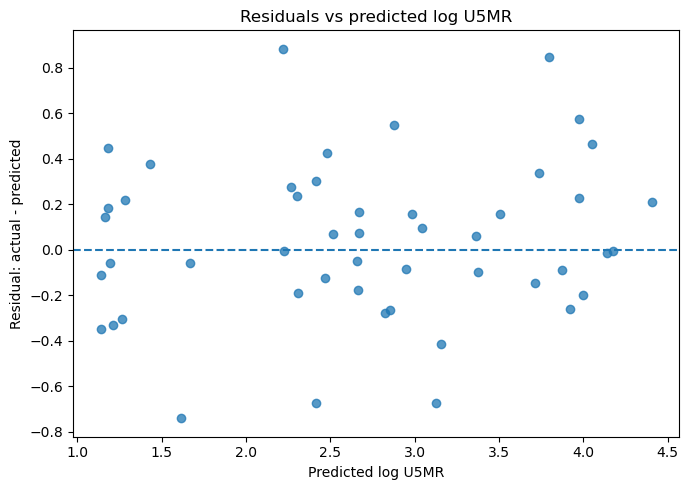

In [733]:
plt.figure(figsize=(7, 5))
plt.scatter(final_predictions["pred_log_u5mr_2023"], final_predictions["residual_log"], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs predicted log U5MR")
plt.xlabel("Predicted log U5MR")
plt.ylabel("Residual: actual - predicted")
plt.tight_layout()
plt.savefig(VIS_DIR / "residuals_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.10 Permutation feature importance

In [735]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = pd.DataFrame({
    "feature": kept_feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_table = importance_table.merge(
    feature_dictionary[["feature", "predictor_name", "feature_type", "domain", "indicator_name"]],
    on="feature",
    how="left"
)

importance_table.to_csv(TABLE_DIR / "permutation_feature_importance.csv", index=False)
display(importance_table.head(15))

,feature,importance_mean,importance_std,predictor_name,feature_type,domain,indicator_name
0,fixed_broadband_subscriptions_2022,0.040112,0.009993,fixed_broadband_subscriptions,value in 2022,infrastructure,Fixed broadband subscriptions (per 100 people)
1,adolescent_fertility_2022,0.034335,0.008852,adolescent_fertility,value in 2022,demographic,"Adolescent fertility rate (births per 1,000 wo..."
2,birth_rate_2022,0.033444,0.011238,birth_rate,value in 2022,demographic,"Birth rate, crude (per 1,000 people)"
3,youth_15_19_share_2022,0.025321,0.007594,youth_15_19_share,value in 2022,demographic,"Population ages 15-19, male (% of male populat..."
4,health_exp_2022,0.024370,0.009968,health_exp,value in 2022,health system,"Current health expenditure per capita, PPP (cu..."
5,health_exp_change_2018_2022,0.022568,0.009167,health_exp,change from 2018 to 2022,health system,"Current health expenditure per capita, PPP (cu..."
6,elderly_share_2022,0.021380,0.007943,elderly_share,value in 2022,demographic,"Population ages 80 and above, male (% of male ..."
7,self_employed_employment_2022,0.019718,0.006389,self_employed_employment,value in 2022,economic,"Self-employed, female (% of female employment)..."
8,prevalence_stunting_height_2022,0.019026,0.006230,prevalence_stunting_height,value in 2022,demographic,"Prevalence of stunting, height for age, male (..."
9,sanitation_access_2022,0.016106,0.006245,sanitation_access,value in 2022,infrastructure,People using at least basic sanitation service...


## 10.11 Feature importance plot

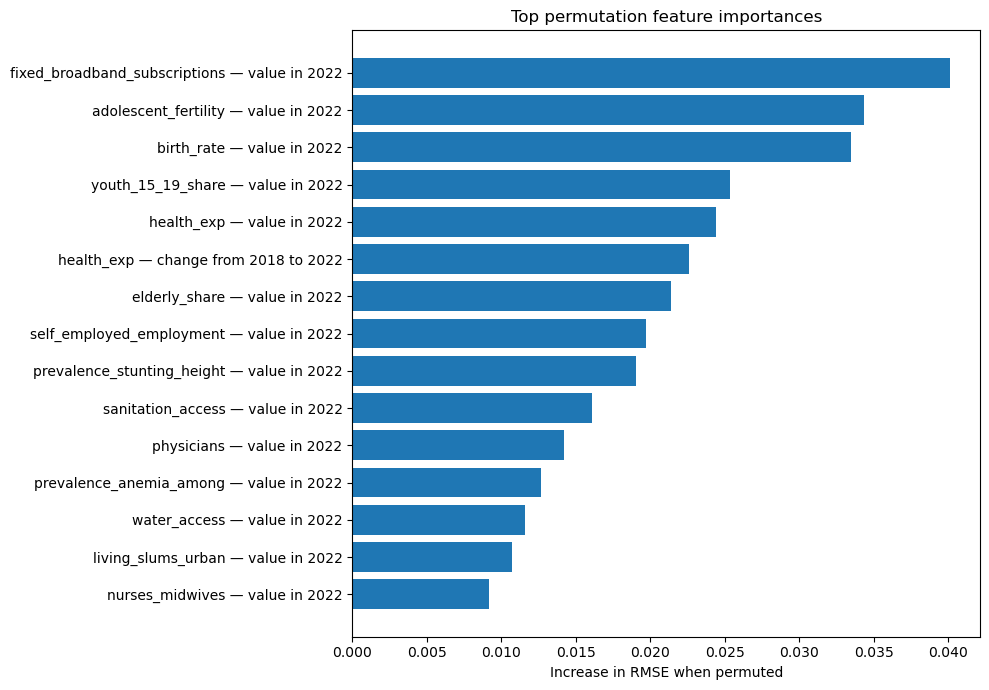

In [737]:
plot_importance = importance_table.head(15).copy().sort_values("importance_mean")
plot_labels = plot_importance["predictor_name"] + " — " + plot_importance["feature_type"]

plt.figure(figsize=(10, 7))
plt.barh(plot_labels, plot_importance["importance_mean"])
plt.title("Top permutation feature importances")
plt.xlabel("Increase in RMSE when permuted")
plt.tight_layout()
plt.savefig(VIS_DIR / "permutation_feature_importance.png", dpi=300)
plt.show()

## 10.12 Report-ready interpretation paragraph

In [739]:
top_importance_rows = importance_table.head(5).copy()

def format_predictor_for_text(row):
    predictor = str(row["predictor_name"]).replace("_", " ")
    feature_type = str(row["feature_type"])
    domain = str(row["domain"])
    return f"{predictor} ({feature_type}; {domain})"

top_predictor_text = "; ".join(
    top_importance_rows.apply(format_predictor_for_text, axis=1).tolist()
)

proxy_predictors = [
    str(name).replace("_", " ")
    for name in top_importance_rows["predictor_name"].dropna().unique()
    if any(term in str(name).lower() for term in ["broadband", "server", "internet", "electricity"])
]

if proxy_predictors:
    proxy_sentence = (
        " Infrastructure and digital-access predictors such as "
        + ", ".join(proxy_predictors)
        + " are interpreted as broad development proxies rather than direct causal mechanisms."
    )
else:
    proxy_sentence = ""

if "subgroup_error_table" in globals() and len(subgroup_error_table) > 0:
    largest_error_row = subgroup_error_table.sort_values("mae_original_scale", ascending=False).iloc[0]
    subgroup_sentence = (
        f" The subgroup diagnostic found the largest mean absolute error in the "
        f"'{largest_error_row['group']}' group under {largest_error_row['grouping_variable']}, "
        f"but subgroup results should be interpreted cautiously because each group contains few countries."
    )
else:
    subgroup_sentence = ""

sample_size_sentence = (
    f" Because the evaluation uses {len(y_test)} test countries and the training set is small, "
    "the reported metrics should be interpreted together with the bootstrap confidence intervals."
)

report_paragraph = (
    f"The selected {final_model_name} model achieved test RMSE_log = {final_metrics['rmse_log']:.3f} "
    f"compared with the dummy baseline RMSE_log = {dummy_metrics['rmse_log']:.3f}, representing a "
    f"{improvement_over_dummy:.1f}% improvement. The test R² of {final_metrics['r2_log']:.3f} means "
    f"the model explains approximately {final_metrics['r2_log'] * 100:.1f}% of the cross-country variation "
    f"in log under-five mortality. The most important predictors were {top_predictor_text}. These variables "
    f"suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, "
    f"and infrastructure are useful for predicting cross-country differences in child mortality."
    f"{proxy_sentence} {sample_size_sentence}{subgroup_sentence} "
    "The results should be interpreted as predictive associations, not causal effects."
)

print(report_paragraph)
with open(REPORT_DIR / "final_report_ready_paragraph.txt", "w", encoding="utf-8") as f:
    f.write(report_paragraph)


The selected Extra Trees tuned model achieved test RMSE_log = 0.346 compared with the dummy baseline RMSE_log = 1.091, representing a 68.3% improvement. The test R² of 0.899 means the model explains approximately 89.9% of the cross-country variation in log under-five mortality. The most important predictors were fixed broadband subscriptions (value in 2022; infrastructure); adolescent fertility (value in 2022; demographic); birth rate (value in 2022; demographic); youth 15 19 share (value in 2022; demographic); health exp (value in 2022; health system). These variables suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, and infrastructure are useful for predicting cross-country differences in child mortality. Infrastructure and digital-access predictors such as fixed broadband subscriptions are interpreted as broad development proxies rather than direct causal mechanisms.  Because the evaluation uses 49 test countries and the trai